In [ ]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import time

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, cohen_kappa_score,
                             classification_report, confusion_matrix)
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader



Using device: cuda


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

CLASS_NAMES = ['Unlabeled', 'Asphalt', 'Meadows', 'Gravel', 'Trees',
               'Painted metal', 'Bare Soil', 'Bitumen', 'Bricks', 'Shadows']
N_CLASSES   = 9

Using device: cuda


## 1. Load data + EDA

Image: (610, 340, 103)  |  Labels: (610, 340)  |  Classes: 0–9

Class distribution:
  Unlabeled      : 164624 pixels
  Asphalt        :   6631 pixels
  Meadows        :  18649 pixels
  Gravel         :   2099 pixels
  Trees          :   3064 pixels
  Painted metal  :   1345 pixels
  Bare Soil      :   5029 pixels
  Bitumen        :   1330 pixels
  Bricks         :   3682 pixels
  Shadows        :    947 pixels


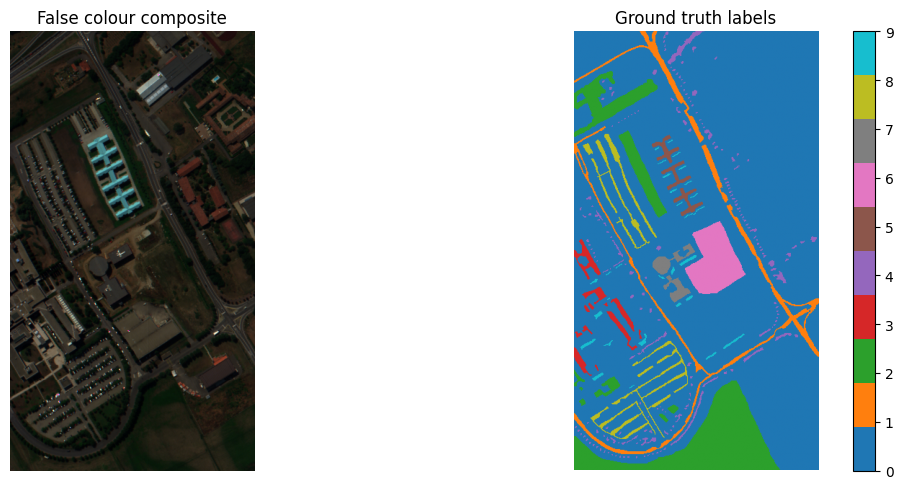

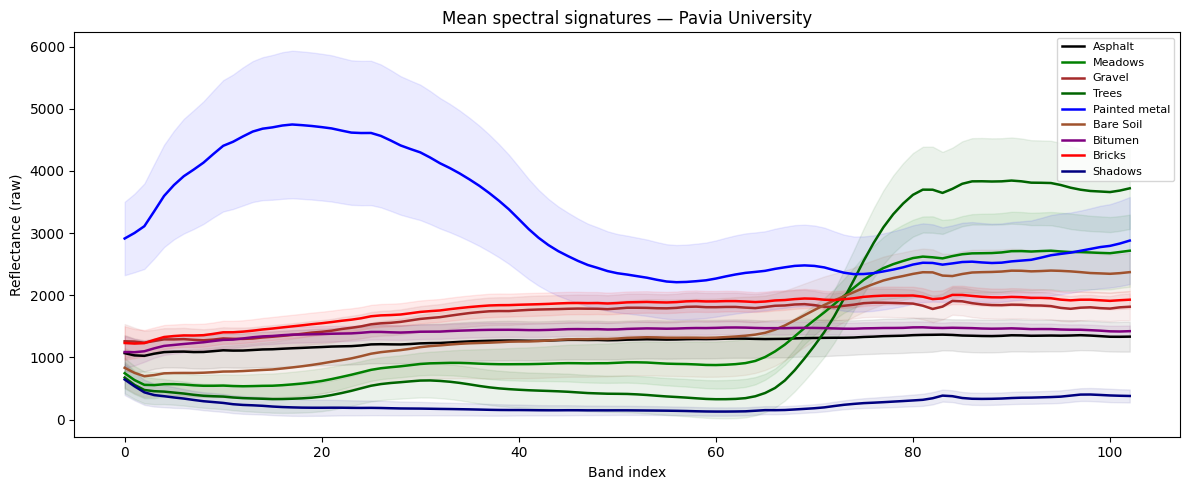

In [2]:
X = sio.loadmat('PaviaU.mat')['paviaU']        # (610, 340, 103)
y = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']  # (610, 340)
H, W, B = X.shape
print(f'Image: {X.shape}  |  Labels: {y.shape}  |  Classes: {y.min()}–{y.max()}')

unique, counts = np.unique(y, return_counts=True)
print('\nClass distribution:')
for cls, cnt in zip(unique, counts):
    print(f'  {CLASS_NAMES[cls]:<15}: {cnt:>6} pixels')

# False colour composite (bands 60/30/10 → R/G/B)
rgb = X[:, :, [60, 30, 10]].astype(np.float32)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(rgb);  axes[0].set_title('False colour composite');  axes[0].axis('off')
im = axes[1].imshow(y, cmap='tab10')
axes[1].set_title('Ground truth labels');  axes[1].axis('off')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

# Spectral signatures
plt.figure(figsize=(12, 5))
colors = ['gray','black','green','brown','darkgreen','blue','sienna','purple','red','navy']
for cls in range(1, 10):
    pixels   = X[y == cls]
    mean_sig = pixels.mean(axis=0)
    std_sig  = pixels.std(axis=0)
    bands    = np.arange(B)
    plt.plot(bands, mean_sig, label=CLASS_NAMES[cls], color=colors[cls], linewidth=1.8)
    plt.fill_between(bands, mean_sig - std_sig, mean_sig + std_sig,
                     color=colors[cls], alpha=0.08)
plt.xlabel('Band index'); plt.ylabel('Reflectance (raw)')
plt.title('Mean spectral signatures — Pavia University')
plt.legend(loc='upper right', fontsize=8); plt.tight_layout(); plt.show()

## 2. Preprocessing — scale · remove background · split

In [3]:
# Scale full cube (fit on all pixels — scaler is unsupervised)
X_flat   = X.reshape(-1, B).astype(np.float32)
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_flat)          # (207400, 103)

# Keep the scaled cube for 3D CNN patch extraction later
X_scaled_cube = X_scaled.reshape(H, W, B)        # (610, 340, 103)

# Remove background (class 0)
y_flat       = y.reshape(-1)                     # (207400,)
labeled_mask = y_flat > 0
X_labeled    = X_scaled[labeled_mask]            # (42776, 103)
y_labeled    = y_flat[labeled_mask]              # (42776,)

print(f'Total pixels   : {len(y_flat):,}')
print(f'Labeled pixels : {labeled_mask.sum():,}')
print(f'Background     : {(~labeled_mask).sum():,}')

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_labeled, y_labeled,
    test_size=0.2, random_state=42, stratify=y_labeled
)
print(f'\nTrain: {X_train.shape}  |  Test: {X_test.shape}')

Total pixels   : 207,400
Labeled pixels : 42,776
Background     : 164,624

Train: (34220, 103)  |  Test: (8556, 103)


## 3. PCA — 103 → 30 bands

Components for 95% variance: 3
Components for 99% variance: 3


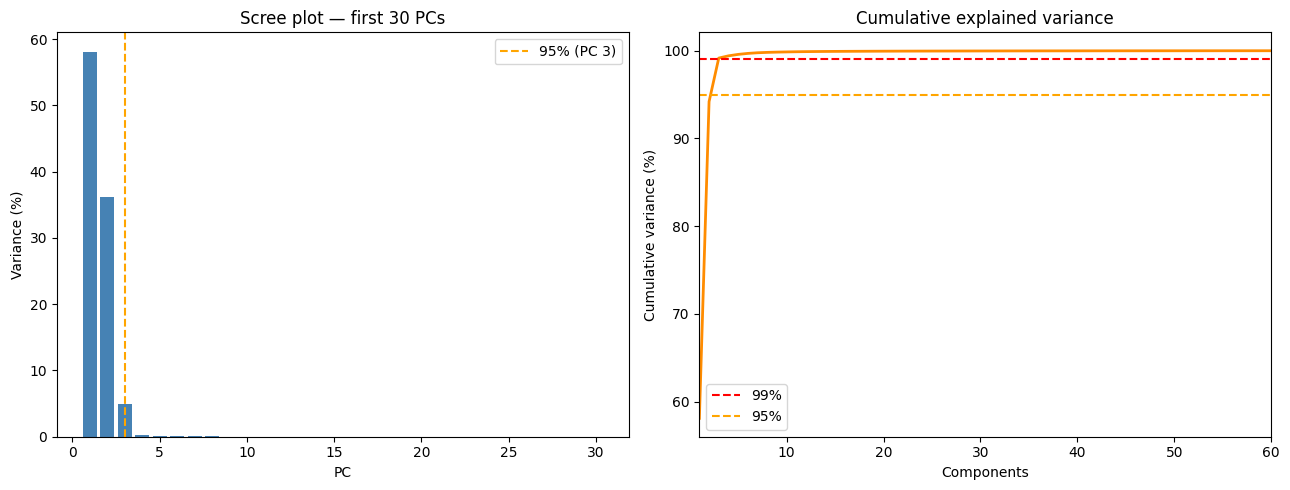


PCA: (34220, 103) → (34220, 30)
Variance retained: 99.97%


In [4]:
# Fit on all 103 components first to find the elbow
pca_full = PCA(n_components=103, random_state=42)
pca_full.fit(X_train)   # fit on train only — no leakage

explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_95 = np.argmax(cumulative >= 0.95) + 1
n_99 = np.argmax(cumulative >= 0.99) + 1
print(f'Components for 95% variance: {n_95}')
print(f'Components for 99% variance: {n_99}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1, 31), explained[:30] * 100, color='steelblue', edgecolor='none')
axes[0].axvline(n_95, color='orange', linestyle='--', label=f'95% (PC {n_95})')
axes[0].set(xlabel='PC', ylabel='Variance (%)', title='Scree plot — first 30 PCs')
axes[0].legend()
axes[1].plot(range(1, 104), cumulative * 100, color='darkorange', linewidth=2)
axes[1].axhline(99, color='red',    linestyle='--', label='99%')
axes[1].axhline(95, color='orange', linestyle='--', label='95%')
axes[1].set(xlabel='Components', ylabel='Cumulative variance (%)',
            title='Cumulative explained variance', xlim=(1, 60))
axes[1].legend()
plt.tight_layout(); plt.show()

# Apply PCA with chosen n_components
N_COMPONENTS  = 30
pca           = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca   = pca.fit_transform(X_train)   # fit on train
X_test_pca    = pca.transform(X_test)        # transform test
print(f'\nPCA: {X_train.shape} → {X_train_pca.shape}')
print(f'Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

## 4. Classical models — SVM · Random Forest · MLP

In [5]:
def evaluate(y_true, y_pred, model_name):
    oa    = accuracy_score(y_true, y_pred) * 100
    kappa = cohen_kappa_score(y_true, y_pred)
    per_class = [
        accuracy_score(y_true[y_true == cls], y_pred[y_true == cls])
        for cls in range(1, 10) if (y_true == cls).sum() > 0
    ]
    aa = np.mean(per_class) * 100
    print(f'\n  {model_name}')
    print(f'  OA={oa:.2f}%  AA={aa:.2f}%  Kappa={kappa:.4f}')
    return {'model': model_name, 'OA': oa, 'AA': aa, 'Kappa': kappa}

# SVM
print('Training SVM...')
t0  = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_pca, y_train)
y_pred_svm = svm.predict(X_test_pca)
print(f'  done in {time.time()-t0:.1f}s')

# Random Forest
print('Training Random Forest...')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train_pca, y_train)
y_pred_rf = rf.predict(X_test_pca)
print(f'  done in {time.time()-t0:.1f}s')

# MLP
print('Training MLP...')
t0  = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu',
                    solver='adam', learning_rate_init=0.001, max_iter=200,
                    early_stopping=True, validation_fraction=0.1,
                    n_iter_no_change=15, random_state=42)
mlp.fit(X_train_pca, y_train)
y_pred_mlp = mlp.predict(X_test_pca)
print(f'  done in {time.time()-t0:.1f}s')

results = [
    evaluate(y_test, y_pred_svm, 'SVM (RBF)'),
    evaluate(y_test, y_pred_rf,  'Random Forest'),
    evaluate(y_test, y_pred_mlp, 'MLP'),
]

Training SVM...
  done in 15.8s
Training Random Forest...
  done in 3.6s
Training MLP...
  done in 119.7s

  SVM (RBF)
  OA=94.52%  AA=92.44%  Kappa=0.9270

  Random Forest
  OA=91.61%  AA=87.35%  Kappa=0.8866

  MLP
  OA=95.77%  AA=94.12%  Kappa=0.9438


## 5. Classical model evaluation — confusion matrix + bar chart

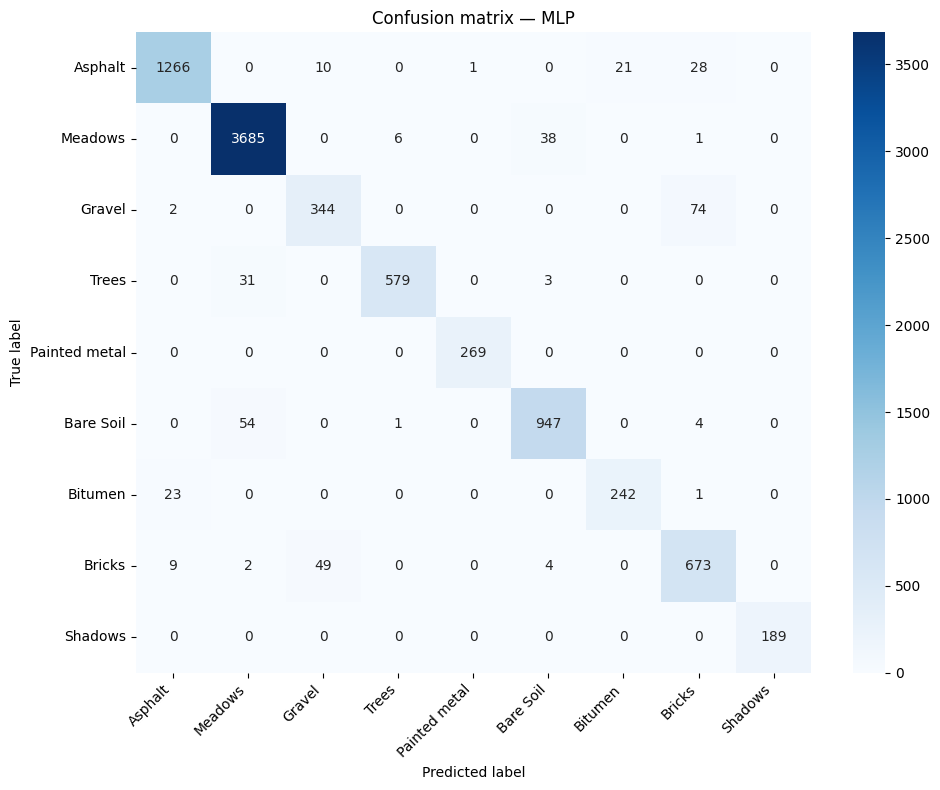

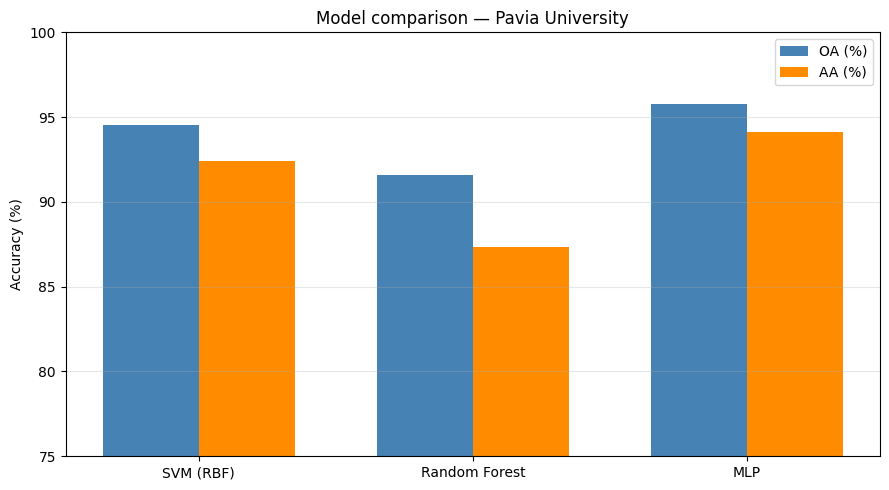

In [6]:
best_pred = y_pred_mlp   # swap to whichever scored highest

cm = confusion_matrix(y_test, best_pred, labels=list(range(1, 10)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES[1:], yticklabels=CLASS_NAMES[1:])
plt.title('Confusion matrix — MLP')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# Model comparison bar chart
models  = [r['model'] for r in results]
oa_vals = [r['OA']    for r in results]
aa_vals = [r['AA']    for r in results]
x, w    = np.arange(len(models)), 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, oa_vals, w, label='OA (%)', color='steelblue')
ax.bar(x + w/2, aa_vals, w, label='AA (%)', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set(ylabel='Accuracy (%)', title='Model comparison — Pavia University', ylim=(75, 100))
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 6. 3D CNN — patch extraction

In [7]:
PATCH_SIZE = 7
HALF       = PATCH_SIZE // 2

# Reflect-pad so edge pixels get full patches
X_padded = np.pad(X_scaled_cube,
                  ((HALF, HALF), (HALF, HALF), (0, 0)),
                  mode='reflect')
print(f'Original: {X_scaled_cube.shape} → Padded: {X_padded.shape}')

def extract_patches(X_pad, y, patch_size=7):
    half = patch_size // 2
    patches, labels, coords = [], [], []
    rows, cols = np.where(y > 0)
    for r, c in zip(rows, cols):
        patch = X_pad[r:r+patch_size, c:c+patch_size, :]  # (7, 7, 103)
        patches.append(patch)
        labels.append(y[r, c])
        coords.append((r, c))
    return (np.array(patches, dtype=np.float32),
            np.array(labels,  dtype=np.int64) - 1,   # shift 1–9 → 0–8
            coords)

print('Extracting patches...')
patches, labels, coords = extract_patches(X_padded, y, PATCH_SIZE)
print(f'Patches: {patches.shape}  |  Labels: {labels.shape}  ({labels.min()}–{labels.max()})')

# Train/test split
idx = np.arange(len(labels))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, stratify=labels, random_state=42
)

class HSIDataset(Dataset):
    def __init__(self, patches, labels):
        # (N,7,7,103) → (N,1,103,7,7)  — Conv3D format
        self.X = torch.tensor(
            patches.transpose(0, 3, 1, 2)[:, np.newaxis],
            dtype=torch.float32
        )
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self):            return len(self.y)
    def __getitem__(self, idx):   return self.X[idx], self.y[idx]

train_loader = DataLoader(HSIDataset(patches[idx_train], labels[idx_train]),
                          batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(HSIDataset(patches[idx_test],  labels[idx_test]),
                          batch_size=128, shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Original: (610, 340, 103) → Padded: (616, 346, 103)
Extracting patches...
Patches: (42776, 7, 7, 103)  |  Labels: (42776,)  (0–8)
Train batches: 268  |  Test batches: 67


## 7. HybridSN model definition

In [8]:
class HybridSN(nn.Module):
    """
    Roy et al. 2020 — 3D conv captures spectral-spatial features,
    2D conv refines spatial patterns, FC classifies.
    Input: (B, 1, 103, 7, 7)
    """
    def __init__(self, num_classes=9, num_bands=103, patch_size=7):
        super().__init__()
        self.conv3d_1 = nn.Sequential(
            nn.Conv3d(1,  8,  kernel_size=(7, 3, 3), padding=0),
            nn.BatchNorm3d(8),  nn.ReLU())
        self.conv3d_2 = nn.Sequential(
            nn.Conv3d(8,  16, kernel_size=(5, 3, 3), padding=0),
            nn.BatchNorm3d(16), nn.ReLU())
        self.conv3d_3 = nn.Sequential(
            nn.Conv3d(16, 32, kernel_size=(3, 1, 1), padding=0),
            nn.BatchNorm3d(32), nn.ReLU())

        self.spectral_out = 91   # 103 - (7-1) - (5-1) - (3-1) = 91
        self.spatial_out  = 3    # 7   - (3-1) - (3-1)         = 3

        self.conv2d_1 = nn.Sequential(
            nn.Conv2d(32 * self.spectral_out, 64, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(64), nn.ReLU())

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * self.spatial_out * self.spatial_out, 256),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.conv3d_1(x)                          # (B, 8,  97, 5, 5)
        x = self.conv3d_2(x)                          # (B, 16, 93, 3, 3)
        x = self.conv3d_3(x)                          # (B, 32, 91, 3, 3)
        x = x.reshape(x.shape[0],
                      32 * self.spectral_out,
                      self.spatial_out,
                      self.spatial_out)               # (B, 32*91, 3, 3)
        x = self.conv2d_1(x)                          # (B, 64,   3, 3)
        return self.classifier(x)

model = HybridSN(num_classes=N_CLASSES).to(device)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {total:,}')

Trainable params: 1,867,241


## 8. Train 3D CNN

Training for 50 epochs on cuda...
Epoch 05/50  loss=0.0364  val_acc=99.02%
Epoch 10/50  loss=0.0184  val_acc=98.24%
Epoch 15/50  loss=0.0139  val_acc=99.88%
Epoch 20/50  loss=0.0114  val_acc=99.65%
Epoch 25/50  loss=0.0047  val_acc=99.30%
Epoch 30/50  loss=0.0119  val_acc=97.76%
Epoch 35/50  loss=0.0009  val_acc=100.00%
Epoch 40/50  loss=0.0019  val_acc=100.00%
Epoch 45/50  loss=0.0015  val_acc=99.85%
Epoch 50/50  loss=0.0008  val_acc=100.00%

Finished in 388s


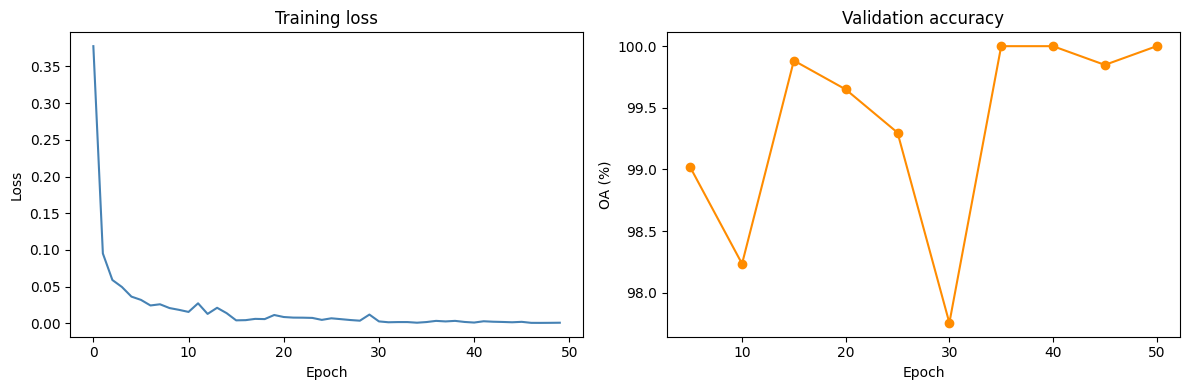

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
EPOCHS    = 50

train_losses, val_accs = [], []
print(f'Training for {EPOCHS} epochs on {device}...')
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))
    scheduler.step()

    if epoch % 5 == 0:
        model.eval()
        correct = total_n = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                out = model(xb.to(device))
                correct  += (out.argmax(1).cpu() == yb).sum().item()
                total_n  += len(yb)
        acc = correct / total_n * 100
        val_accs.append(acc)
        print(f'Epoch {epoch:02d}/{EPOCHS}  loss={train_losses[-1]:.4f}  val_acc={acc:.2f}%')

print(f'\nFinished in {time.time()-t0:.0f}s')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color='steelblue')
ax1.set(xlabel='Epoch', ylabel='Loss', title='Training loss')
ax2.plot(range(5, EPOCHS+1, 5), val_accs, color='darkorange', marker='o')
ax2.set(xlabel='Epoch', ylabel='OA (%)', title='Validation accuracy')
plt.tight_layout(); plt.show()

## 9. Evaluate 3D CNN

In [10]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        all_preds.extend(model(xb.to(device)).argmax(1).cpu().numpy())
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

oa    = accuracy_score(all_labels, all_preds) * 100
kappa = cohen_kappa_score(all_labels, all_preds)
per_class = [
    accuracy_score(all_labels[all_labels == cls], all_preds[all_labels == cls])
    for cls in range(N_CLASSES) if (all_labels == cls).sum() > 0
]
aa = np.mean(per_class) * 100

print(f'3D CNN (HybridSN)  OA={oa:.2f}%  AA={aa:.2f}%  Kappa={kappa:.4f}')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES[1:], digits=4))

3D CNN (HybridSN)  OA=100.00%  AA=100.00%  Kappa=1.0000
               precision    recall  f1-score   support

      Asphalt     1.0000    1.0000    1.0000      1326
      Meadows     1.0000    1.0000    1.0000      3730
       Gravel     1.0000    1.0000    1.0000       420
        Trees     1.0000    1.0000    1.0000       613
Painted metal     1.0000    1.0000    1.0000       269
    Bare Soil     1.0000    1.0000    1.0000      1006
      Bitumen     1.0000    1.0000    1.0000       266
       Bricks     1.0000    1.0000    1.0000       737
      Shadows     1.0000    1.0000    1.0000       189

     accuracy                         1.0000      8556
    macro avg     1.0000    1.0000    1.0000      8556
 weighted avg     1.0000    1.0000    1.0000      8556



## 10. Full prediction maps + error maps + zoom

Generating 3D CNN full map (batched)...
Done.


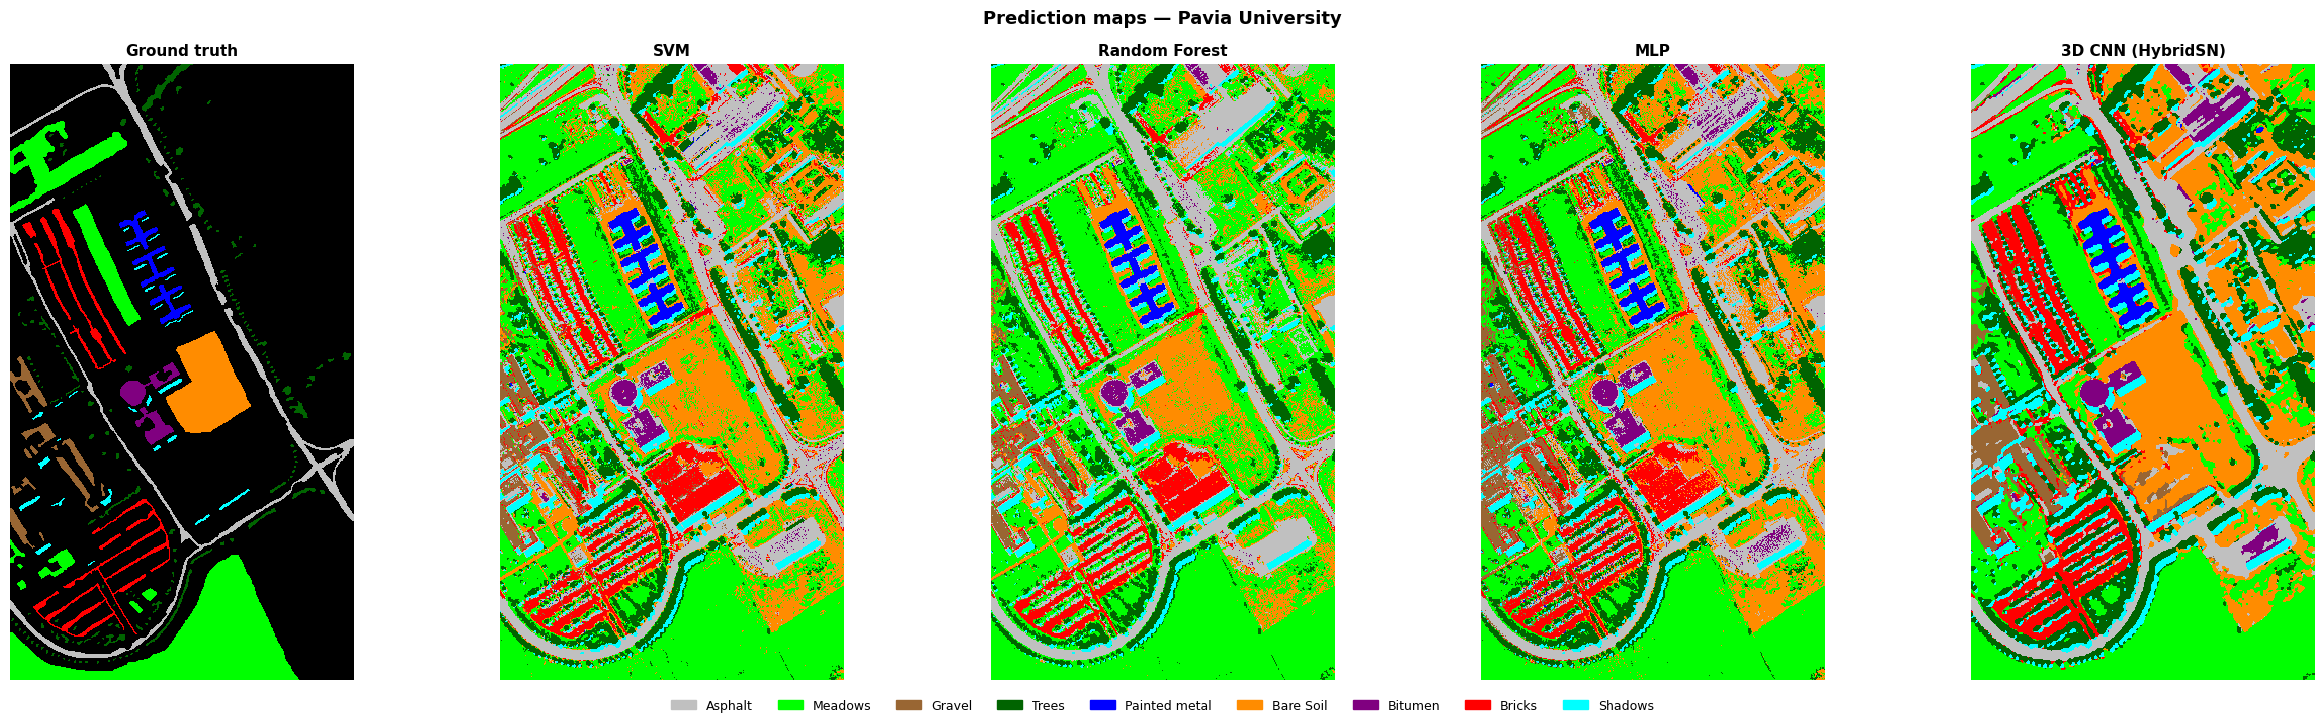

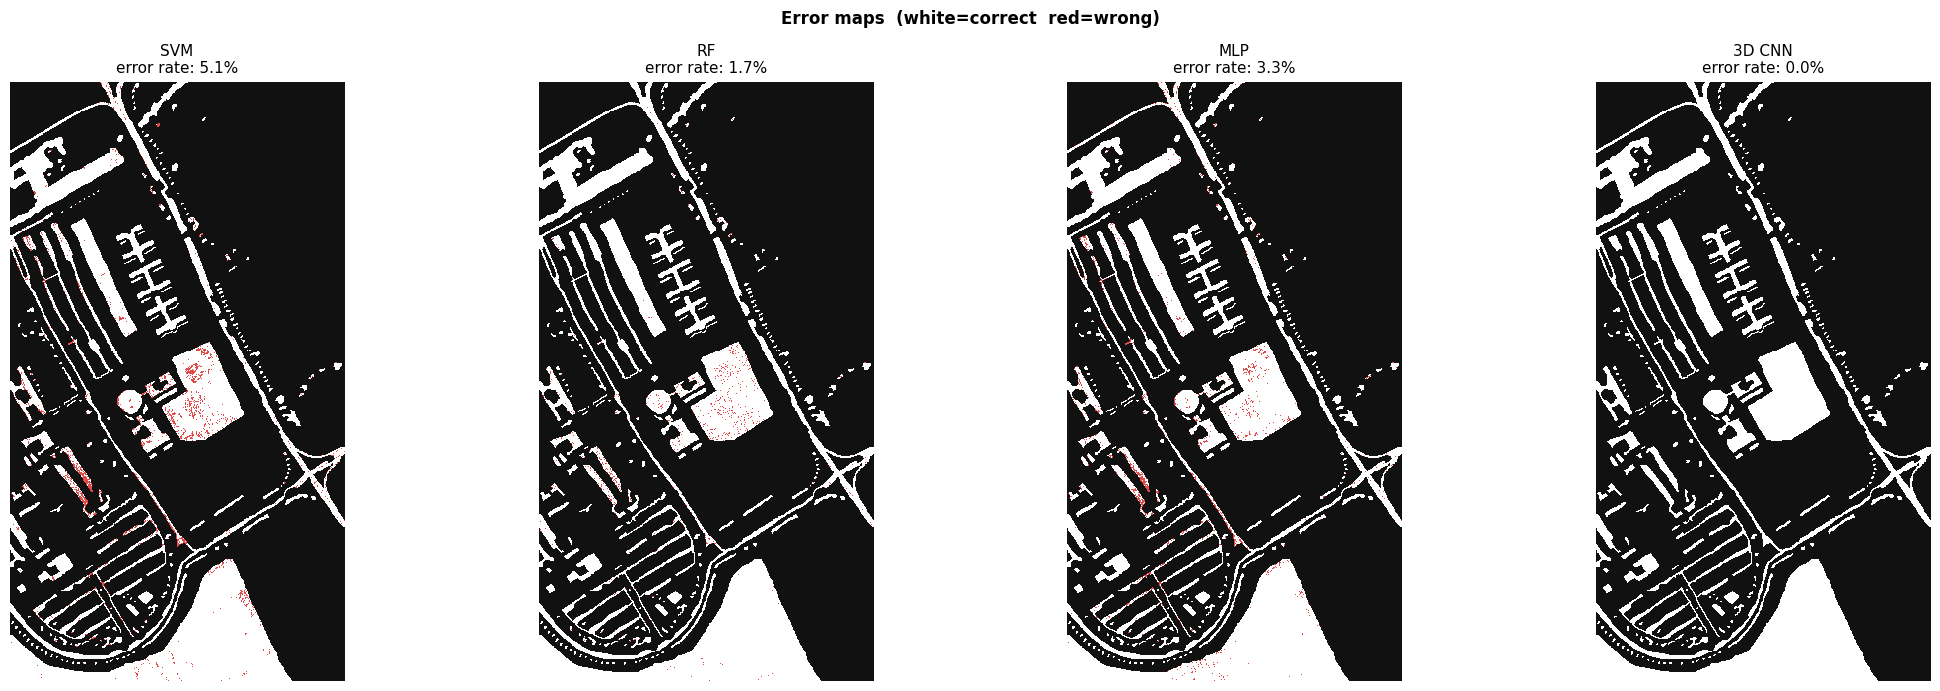

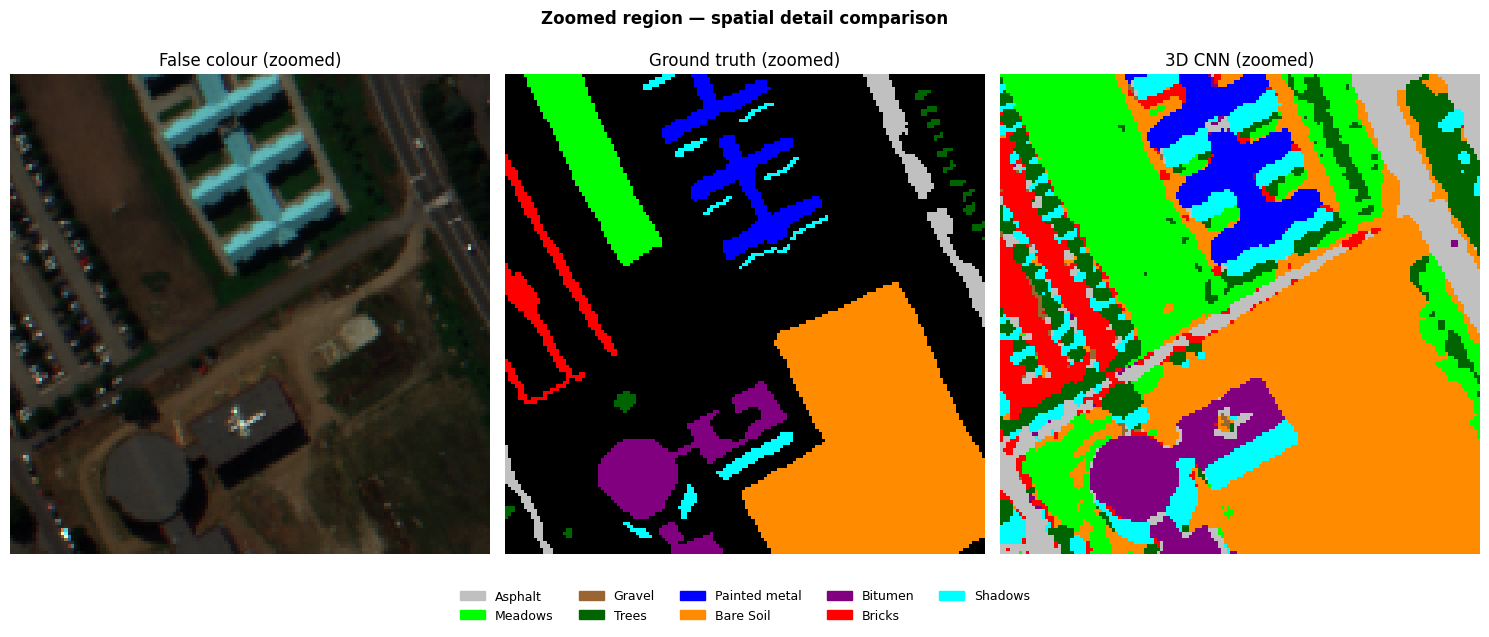

In [11]:
# ── Colour map (standard Pavia University colours) ────────────
COLORS = ['#000000','#C0C0C0','#00FF00','#996633','#006400',
          '#0000FF','#FF8C00','#800080','#FF0000','#00FFFF']
cmap   = ListedColormap(COLORS)

def make_legend():
    return [mpatches.Patch(color=COLORS[i], label=CLASS_NAMES[i])
            for i in range(1, 10)]

# ── Classical model maps (PCA features → flat prediction) ─────
X_flat_full   = X_scaled_cube.reshape(-1, B)
X_pca_full    = pca.transform(X_flat_full)    # (207400, 30)

pred_svm = (svm.predict(X_pca_full) ).reshape(H, W).astype(np.int8)
pred_rf  = (rf.predict(X_pca_full)  ).reshape(H, W).astype(np.int8)
pred_mlp = (mlp.predict(X_pca_full) ).reshape(H, W).astype(np.int8)

# ── 3D CNN map (batched to avoid OOM) ─────────────────────────
print('Generating 3D CNN full map (batched)...')
pred_3dcnn = np.zeros((H, W), dtype=np.int8)
BATCH      = 512

all_rows, all_cols = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
all_rows, all_cols = all_rows.ravel(), all_cols.ravel()

patches_full = []
for r, c in zip(all_rows, all_cols):
    patches_full.append(X_padded[r:r+PATCH_SIZE, c:c+PATCH_SIZE, :])
patches_full = np.array(patches_full, dtype=np.float32)         # (207400,7,7,103)
patches_full = patches_full.transpose(0, 3, 1, 2)[:, np.newaxis]  # (207400,1,103,7,7)

model.eval()
preds_flat = []
with torch.no_grad():
    for i in range(0, len(patches_full), BATCH):
        xb = torch.tensor(patches_full[i:i+BATCH]).to(device)
        preds_flat.extend(model(xb).argmax(1).cpu().numpy() + 1)  # shift back 0–8 → 1–9
        del xb; torch.cuda.empty_cache()
pred_3dcnn = np.array(preds_flat).reshape(H, W).astype(np.int8)
print('Done.')

# ── Ground truth map ──────────────────────────────────────────
gt_map = y.astype(int)

# ── 4-model prediction map grid ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(25, 7))
panels = [
    (gt_map,    'Ground truth'),
    (pred_svm,  'SVM'),
    (pred_rf,   'Random Forest'),
    (pred_mlp,  'MLP'),
    (pred_3dcnn,'3D CNN (HybridSN)'),
]
for ax, (m, title) in zip(axes, panels):
    ax.imshow(m, cmap=cmap, vmin=0, vmax=9, interpolation='nearest')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axis('off')
fig.legend(handles=make_legend(), loc='lower center', ncol=9,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Prediction maps — Pavia University', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Error maps ────────────────────────────────────────────────
def make_error_map(pred, gt):
    err = np.zeros_like(gt, dtype=np.uint8)
    labeled  = gt > 0
    err[labeled & (pred == gt)] = 1   # correct → white
    err[labeled & (pred != gt)] = 2   # wrong   → red
    return err

err_cmap = ListedColormap(['#111111', '#FFFFFF', '#E24B4A'])
fig, axes = plt.subplots(1, 4, figsize=(22, 7))
for ax, (pred, name) in zip(axes, [
        (pred_svm, 'SVM'), (pred_rf, 'RF'), (pred_mlp, 'MLP'), (pred_3dcnn, '3D CNN')]):
    err      = make_error_map(pred, gt_map)
    err_rate = (err == 2).sum() / (gt_map > 0).sum() * 100
    ax.imshow(err, cmap=err_cmap, vmin=0, vmax=2, interpolation='nearest')
    ax.set_title(f'{name}\nerror rate: {err_rate:.1f}%', fontsize=11)
    ax.axis('off')
plt.suptitle('Error maps  (white=correct  red=wrong)', fontweight='bold')
plt.tight_layout(); plt.show()

# ── Zoomed region comparison ───────────────────────────────────
R1, R2, C1, C2 = 200, 350, 80, 230
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(rgb[R1:R2, C1:C2],         interpolation='nearest')
axes[0].set_title('False colour (zoomed)', fontsize=12); axes[0].axis('off')
axes[1].imshow(gt_map[R1:R2, C1:C2],      cmap=cmap, vmin=0, vmax=9, interpolation='nearest')
axes[1].set_title('Ground truth (zoomed)', fontsize=12); axes[1].axis('off')
axes[2].imshow(pred_3dcnn[R1:R2, C1:C2],  cmap=cmap, vmin=0, vmax=9, interpolation='nearest')
axes[2].set_title('3D CNN (zoomed)',        fontsize=12); axes[2].axis('off')
fig.legend(handles=make_legend(), loc='lower center', ncol=5,
           fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.06))
plt.suptitle('Zoomed region — spatial detail comparison', fontweight='bold')
plt.tight_layout(); plt.show()